/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leadin

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.438879,0.043543,-0.023159,0.035348,17105,20.798881
2,-0.257440,0.061699,-0.015174,0.025794,16151,19.638862
3,-0.193804,0.090005,-0.011611,0.022860,15917,19.354329
4,-0.162117,0.141300,-0.006919,0.020148,16162,19.652237
5,-0.134948,0.794655,0.014013,0.057087,16905,20.555691


Returns Analysis


,1D,5D,10D
Ann. alpha,0.189,0.110,0.054
beta,-0.030,-0.016,0.003
Mean Period Wise Return Top Quantile (bps),8.584,4.593,2.808
Mean Period Wise Return Bottom Quantile (bps),-9.621,-8.054,-6.785
Mean Period Wise Spread (bps),18.205,12.488,9.658


<Figure size 640x480 with 0 Axes>

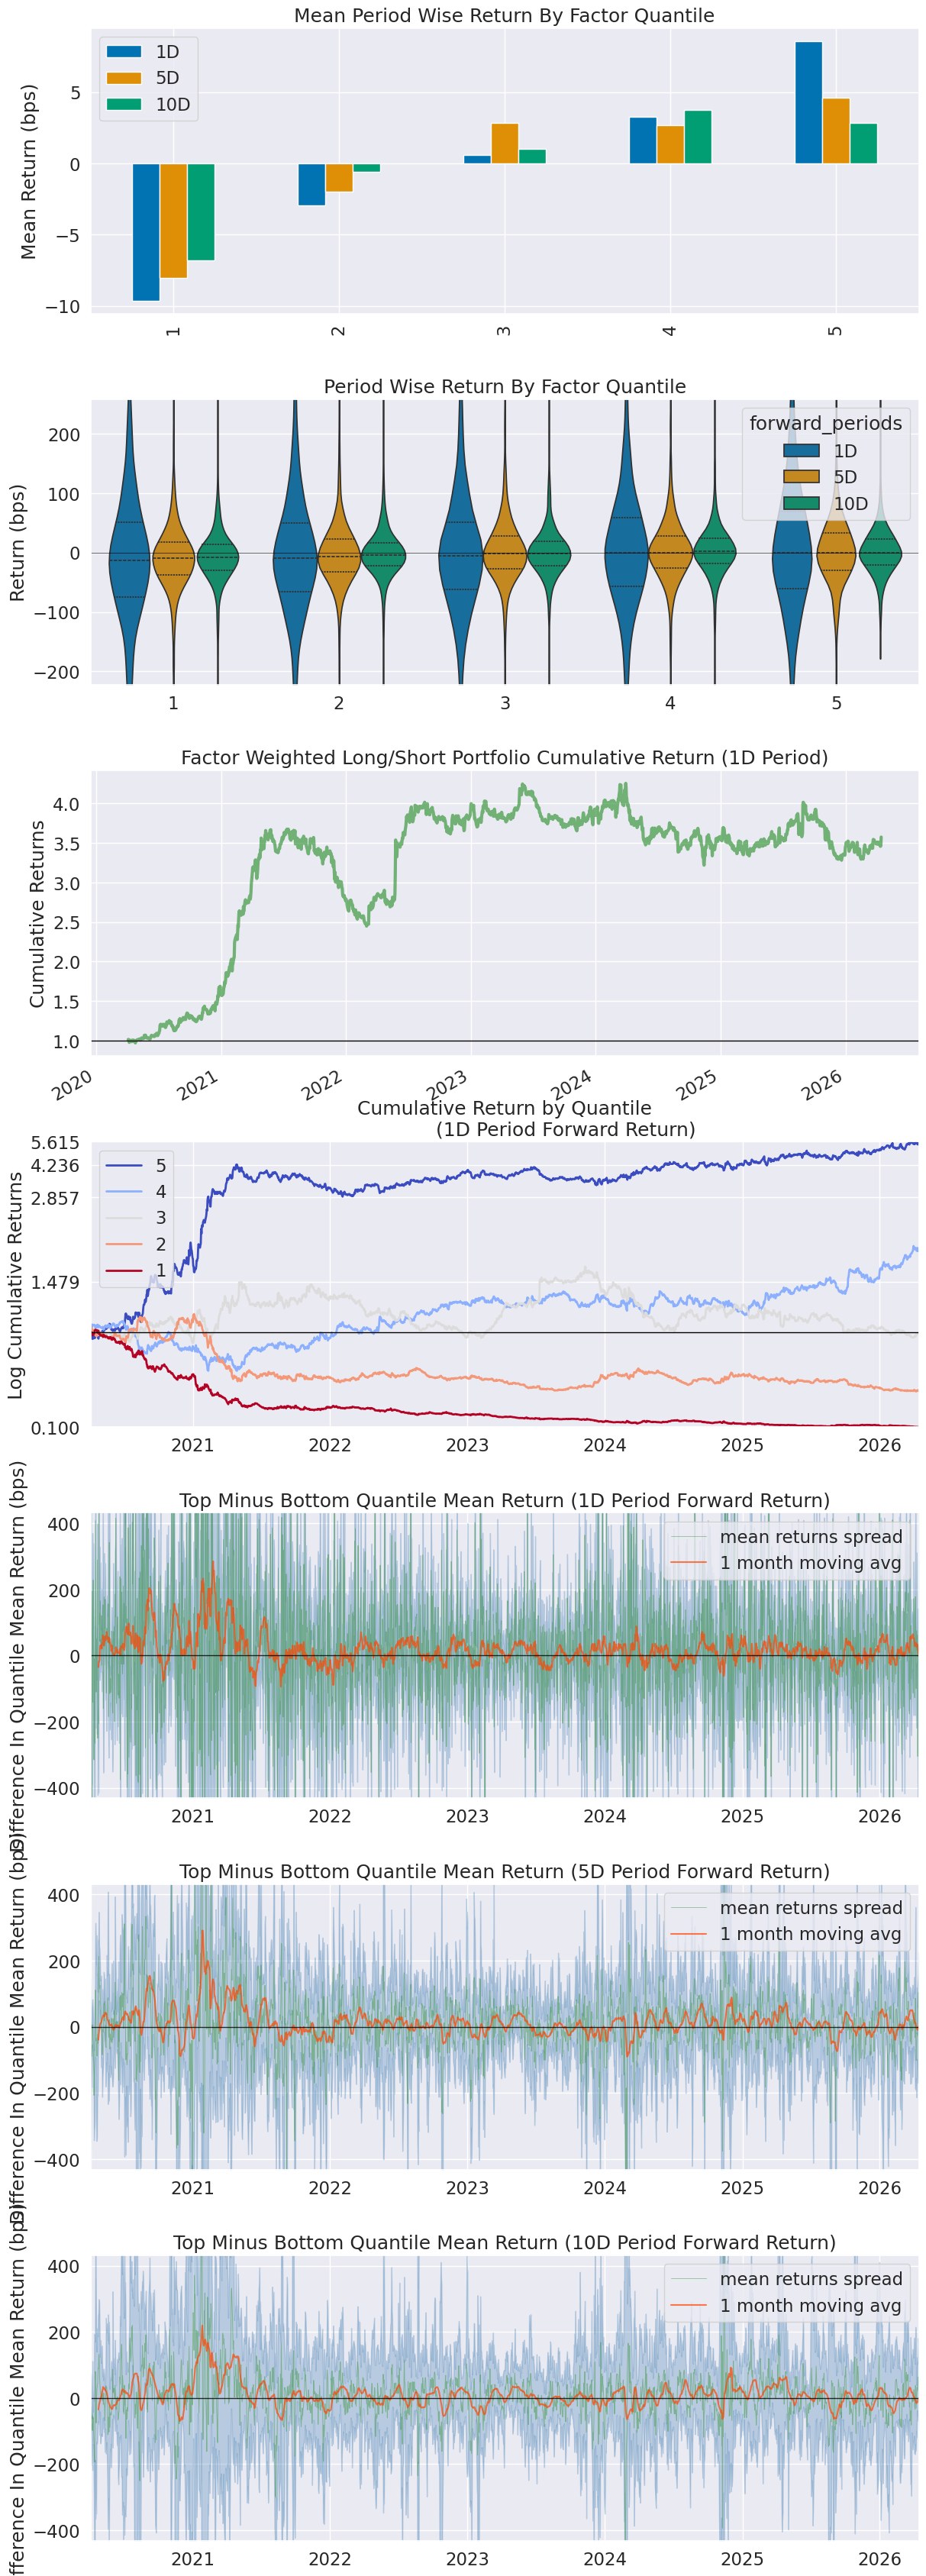

Information Analysis


,1D,5D,10D
IC Mean,0.028,0.039,0.043
IC Std.,0.191,0.186,0.177
Risk-Adjusted IC,0.146,0.210,0.245
t-stat(IC),6.870,9.855,11.486
p-value(IC),0.000,0.000,0.000
IC Skew,0.002,-0.026,0.001
IC Kurtosis,-0.119,-0.052,-0.009


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


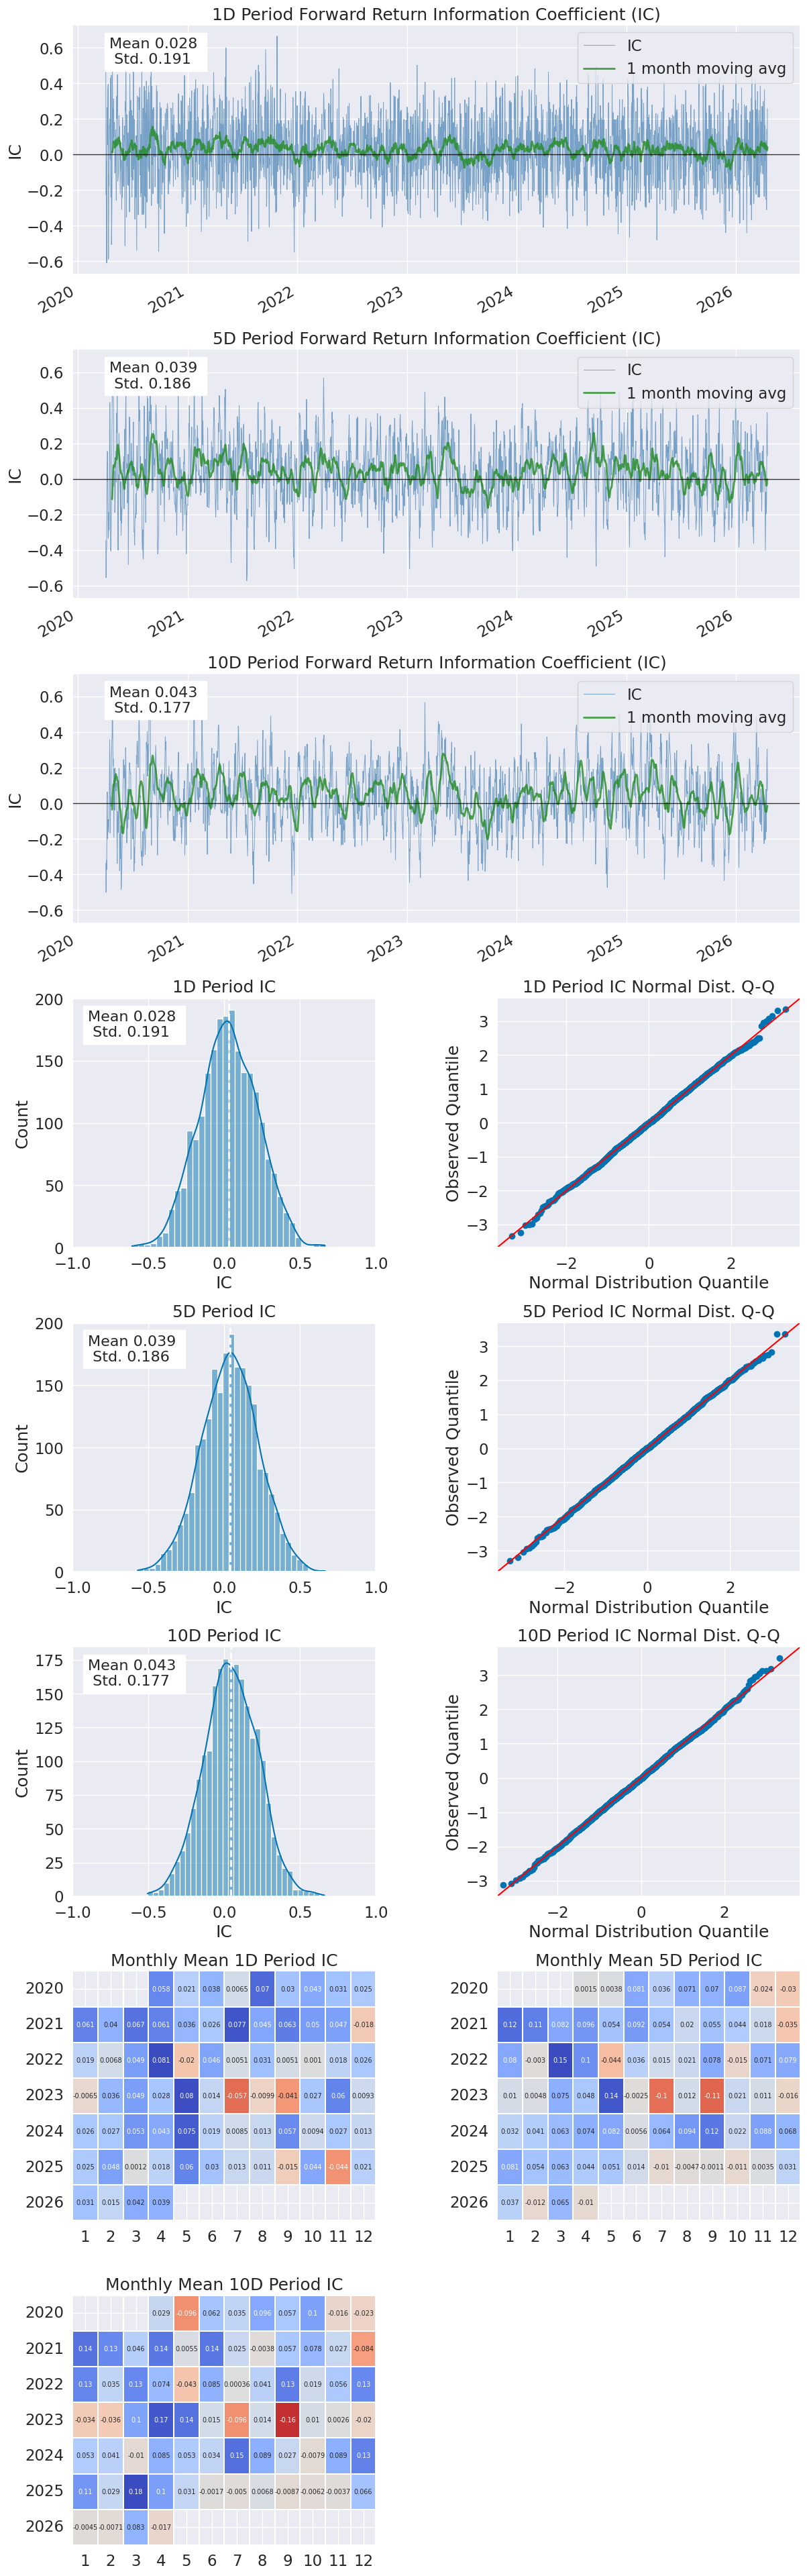

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.232,0.549,0.617
Quantile 2 Mean Turnover,0.438,0.715,0.742
Quantile 3 Mean Turnover,0.464,0.734,0.768
Quantile 4 Mean Turnover,0.389,0.694,0.737
Quantile 5 Mean Turnover,0.175,0.432,0.504


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.915,0.586,0.498


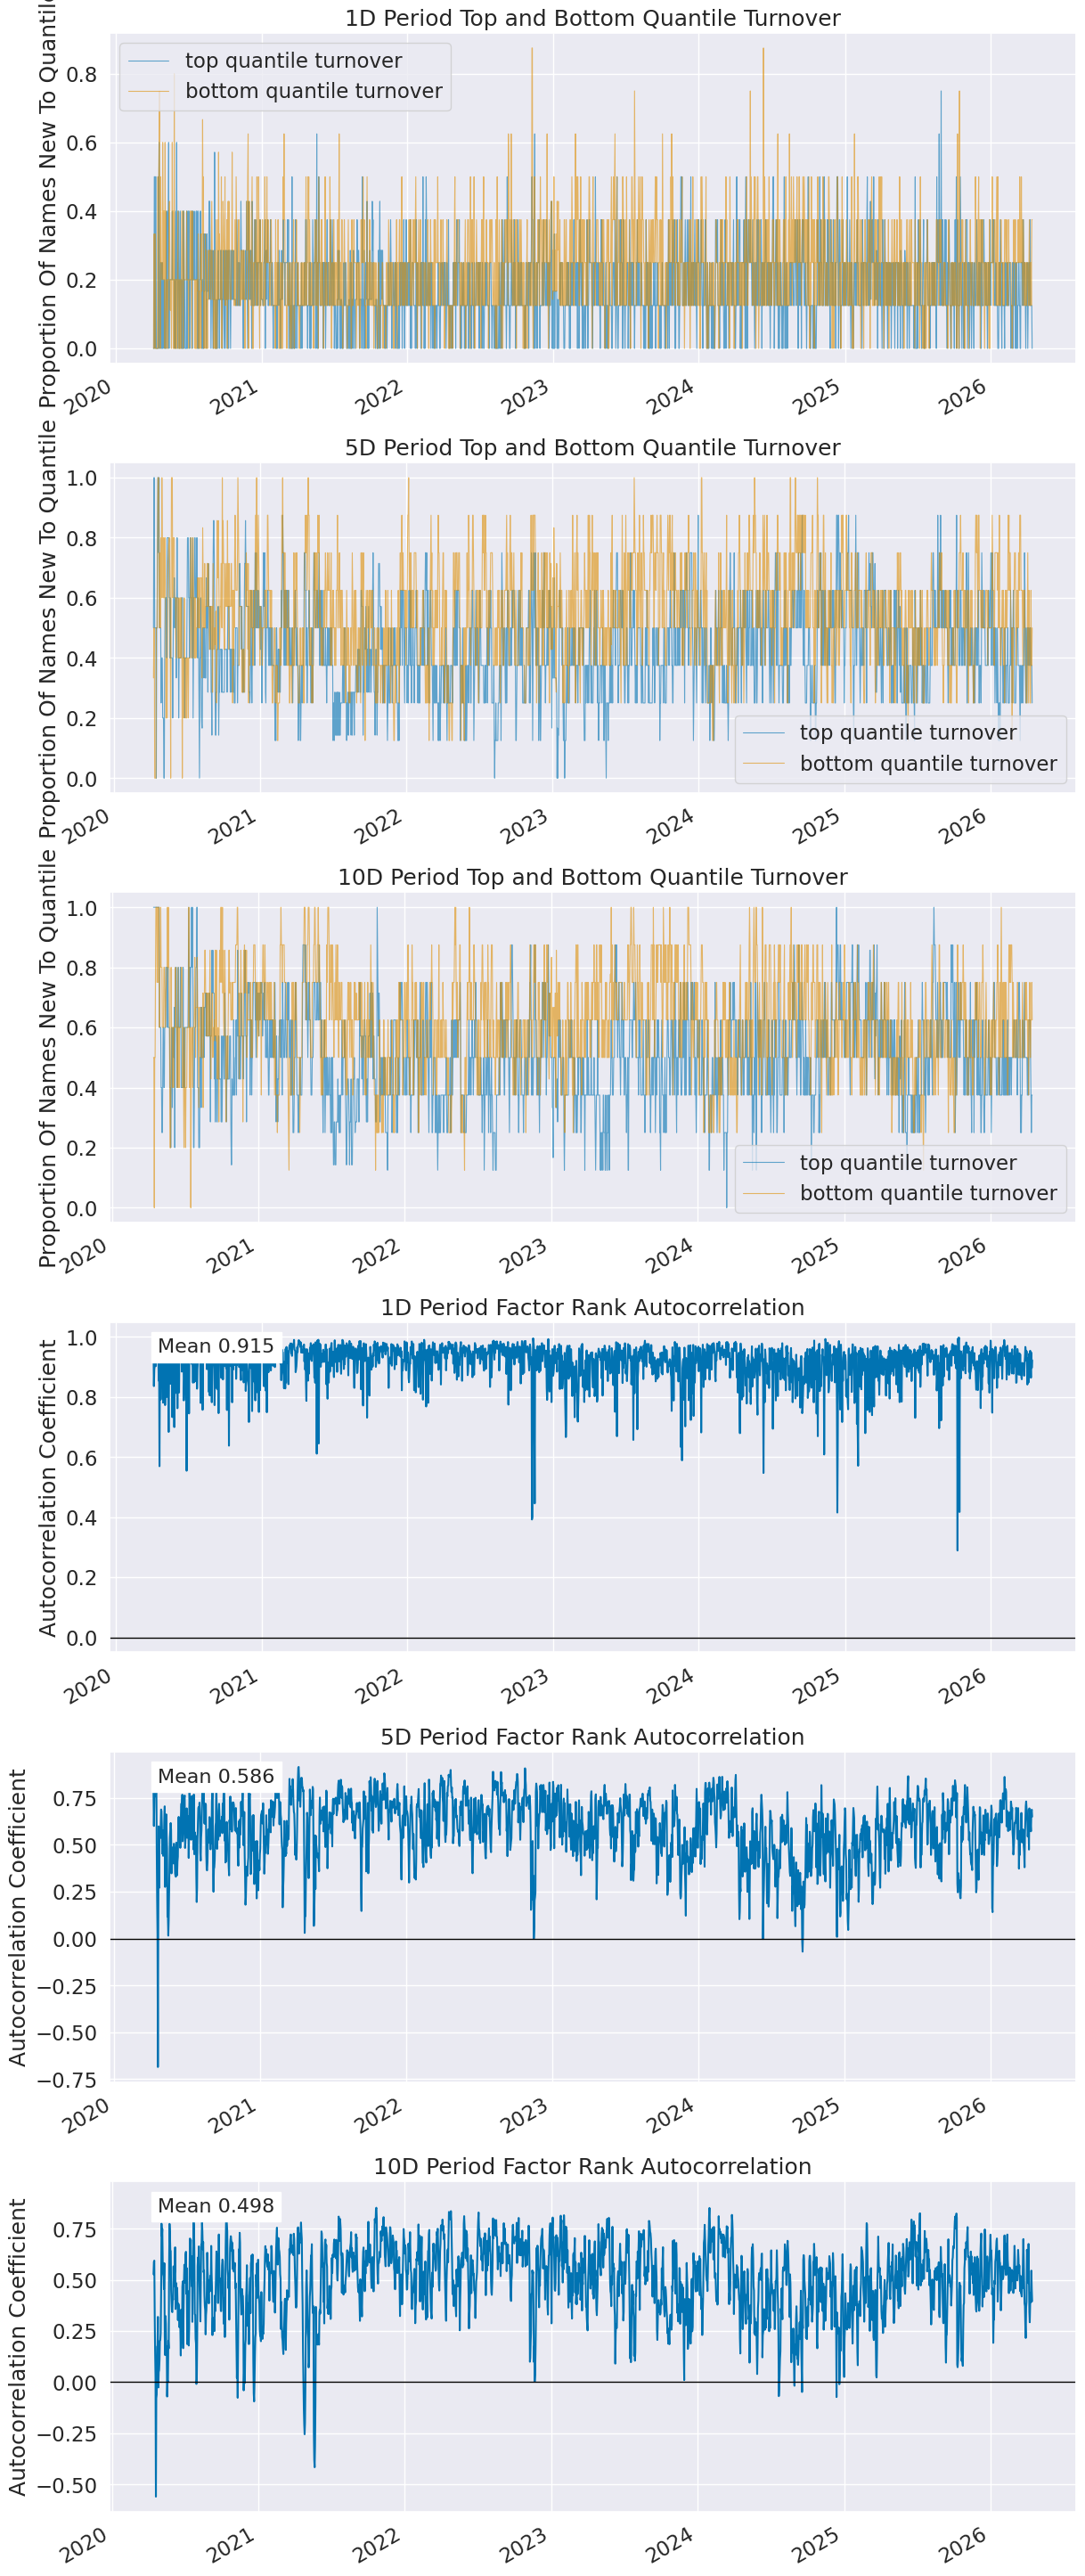

In [1]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "notebooks" / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
for _p in (_root, _root / "notebooks"):
    sys.path.insert(0, str(_p))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Enhanced Carry -- portfolio carry_enhanced.40
portfolio = "carry_enhanced"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Mask the raw factor with the dynamic point-in-time universe (a boolean
# dates x tickers matrix) so AlphaLens scores only the universe we trade,
# not every ticker that was ever tradeable.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)